# Most Stocks Lose \U0001F3B2
### Except these ones. Which turned out to be the more useful finding.

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The best-known statistic in this corner of finance says most stocks lose to Treasury bills. We
went to check it on fifty large US companies and it **was not there** — the longer you held, the
*more* likely you were to win. Chasing down why produced a single inequality that says exactly
when the famous result holds and when it does not.

> \U0001F4D3 **This is the plain-language layer.** The drag decomposition, the odds table and
> the one-knob control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the typical *surviving large cap* beat cash? | Yes — more often the longer you hold. |
| So is the famous result wrong? | No. It is about a different population. |
| What separates the two? | One number: volatility versus √(2·(drift−cash)). |
| Does anything from it survive here? | Yes — the concentration of the gains. |

> This study was written expecting to confirm "most stocks lose". On this basket it **failed**,
> and chasing down why produced something better: the exact condition under which the result
> holds.

## 1 · Fifty stocks, thirty years

In [2]:
from moststocks import data, strategy as st

px = data.load_prices()
cols = [c for c in data.NAMES if c in px.columns and px[c].dropna().shape[0] > 2000]
R = px[cols].pct_change().dropna()
cash = (px[data.BILLS].pct_change().reindex(R.index).fillna(0.0)
        if data.BILLS in px.columns
        else pd.Series(np.full(len(R), 0.02/252), index=R.index))
print(f"as-of {data.AS_OF} | {len(cols)} names, {len(R):,} sessions from "
      f"{R.index[0].date()} ({len(R)/252:.1f} years)")
print("All of them survived to 2026 -- the hardest possible place to find this effect.")

as-of 2026-06-30 | 50 names, 4,146 sessions from 2010-01-05 (16.5 years)
All of them survived to 2026 -- the hardest possible place to find this effect.


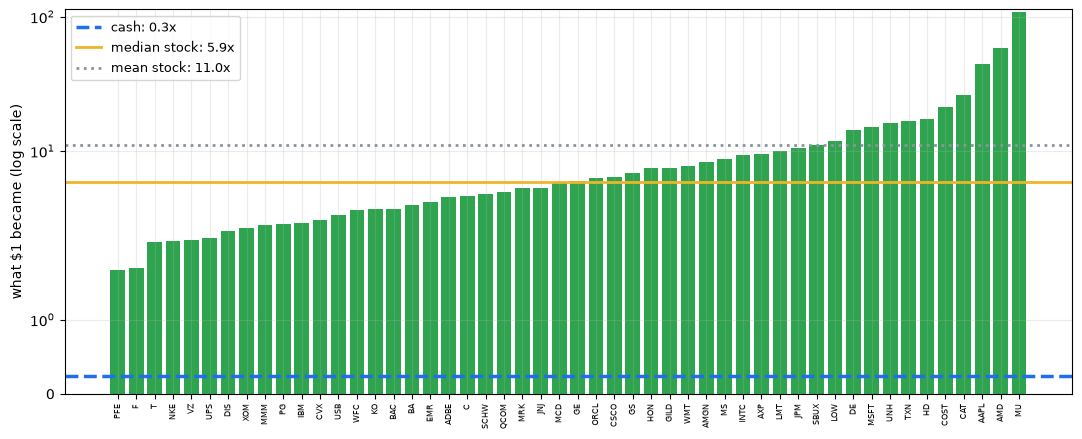

median 5.9x, mean 11.0x -- the mean is dragged up by a few


In [3]:
finals = np.expm1(np.log1p(R).sum())
cash_total = np.expm1(np.log1p(cash).sum())
s = finals.sort_values()
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(s)), s, color=["#c0392b" if v < cash_total else "#2ea44f" for v in s])
ax.axhline(cash_total, color="#1f6feb", lw=2.5, ls="--",
           label=f"cash: {cash_total:.1f}x")
ax.axhline(s.median(), color="#f0b429", lw=2, label=f"median stock: {s.median():.1f}x")
ax.axhline(s.mean(), color="#8b949e", lw=2, ls=":", label=f"mean stock: {s.mean():.1f}x")
ax.set_yscale("symlog"); ax.set_xticks(range(len(s)))
ax.set_xticklabels(s.index, rotation=90, fontsize=6)
ax.set_ylabel("what $1 became (log scale)"); ax.legend(fontsize=9)
plt.show()
print(f"median {s.median():.1f}x, mean {s.mean():.1f}x -- the mean is dragged up by a few")

## 2 · The result that did not appear

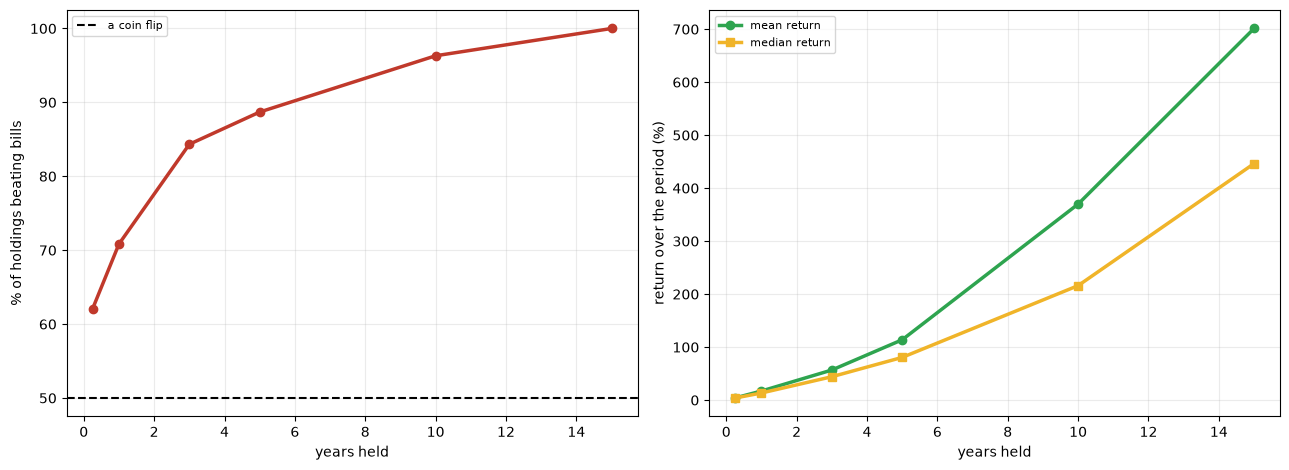

         share_beat_cash  median_return  mean_return    skew
years                                                       
0.2500            0.6210         0.0390       0.0400 -0.3870
1.0000            0.7080         0.1340       0.1710  0.0850
3.0000            0.8430         0.4410       0.5670  0.1200
5.0000            0.8870         0.8060       1.1380  0.2710
10.0000           0.9630         2.1600       3.6990  0.6900
15.0000           1.0000         4.4640       7.0130  0.4760


In [4]:
sw = st.horizon_sweep(R, cash, horizons_years=(0.25, 1, 3, 5, 10, 15))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(sw.index, sw["share_beat_cash"] * 100, "o-", lw=2.5, color="#c0392b")
axes[0].axhline(50, color="k", ls="--", lw=1.5, label="a coin flip")
axes[0].set_xlabel("years held"); axes[0].set_ylabel("% of holdings beating bills")
axes[0].legend(fontsize=8)
axes[1].plot(sw.index, sw["mean_return"] * 100, "o-", lw=2.5, color="#2ea44f",
             label="mean return")
axes[1].plot(sw.index, sw["median_return"] * 100, "s-", lw=2.5, color="#f0b429",
             label="median return")
axes[1].set_xlabel("years held"); axes[1].set_ylabel("return over the period (%)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(sw[["share_beat_cash", "median_return", "mean_return", "skew"]].round(3).to_string())

The left panel was supposed to slope **down**. It slopes up: on these fifty survivors, holding
longer makes you *more* likely to beat bills, not less.

So the famous result is not a general property of stocks. What is it a property of?

## 2b · The one number that decides it

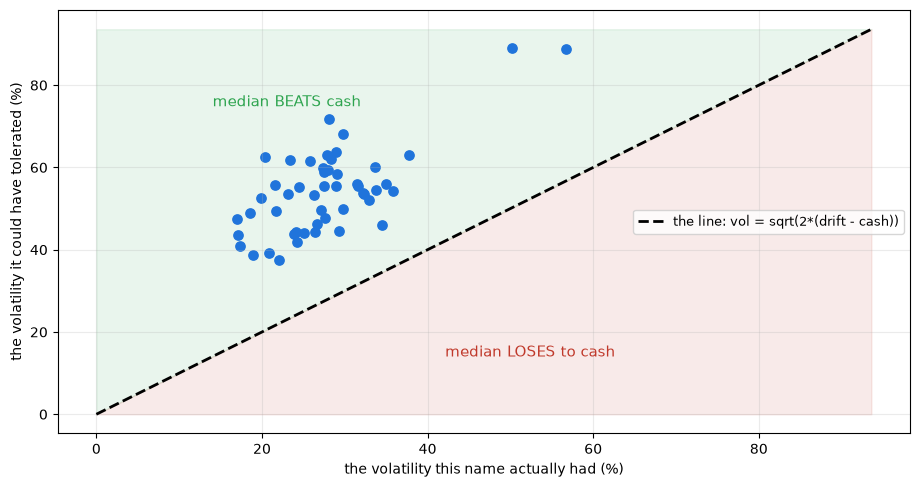

average drift 16.7%, cash 1.4%
-> breakeven volatility 54%, actual 28%
only 0% of these names are on the wrong side


In [5]:
cond = st.median_beats_cash_condition(R, cash)
tab = cond["table"]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(tab["vol"] * 100, tab["breakeven_vol"] * 100, s=45, color="#1f6feb")
lim = [0, max(tab["breakeven_vol"].max(), tab["vol"].max()) * 105]
ax.plot(lim, lim, "k--", lw=2, label="the line: vol = sqrt(2*(drift - cash))")
ax.fill_between(lim, lim, lim[1], alpha=0.10, color="#2ea44f")
ax.fill_between(lim, 0, lim, alpha=0.10, color="#c0392b")
ax.annotate("median BEATS cash", (lim[1]*0.15, lim[1]*0.8), fontsize=11,
            color="#2ea44f")
ax.annotate("median LOSES to cash", (lim[1]*0.45, lim[1]*0.15), fontsize=11,
            color="#c0392b")
ax.set_xlabel("the volatility this name actually had (%)")
ax.set_ylabel("the volatility it could have tolerated (%)")
ax.legend(fontsize=9)
plt.show()
print(f"average drift {cond['mean_drift']:.1%}, cash {cond['cash_log_growth']:.1%}")
print(f"-> breakeven volatility {cond['mean_breakeven']:.0%}, "
      f"actual {cond['mean_vol']:.0%}")
print(f"only {cond['share_above_threshold']:.0%} of these names are on the wrong side")

Every point above the dashed line is a stock whose median holder wins. Almost all of them are.

The condition is simply **σ < √(2 × (drift − cash))**. Raise a company's volatility or lower its
drift and it crosses the line. Bessembinder's universe — small companies, and companies on their
way to being delisted — lives on the other side of it.

## 3 · Why: compounding is multiplication

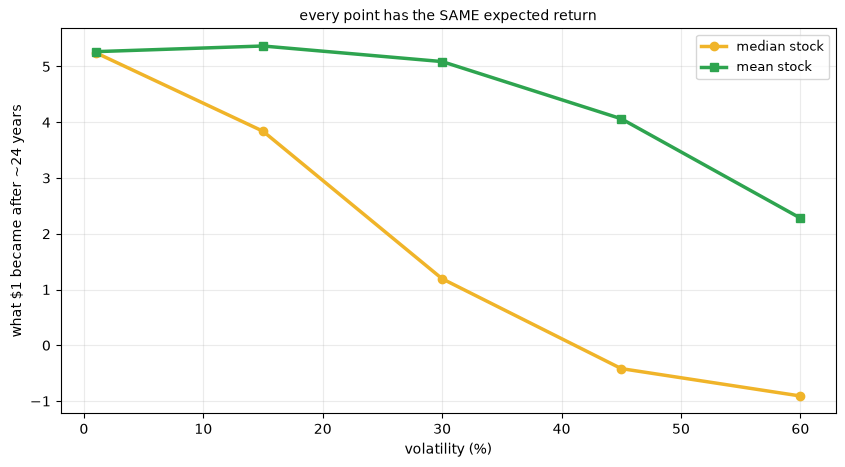

            expected return  median outcome  mean outcome
volatility                                               
0.0100               0.0770          5.2460        5.2660
0.1500               0.0790          3.8390        5.3680
0.3000               0.0810          1.1930        5.0880
0.4500               0.0820         -0.4180        4.0620
0.6000               0.0840         -0.9100        2.2810


In [6]:
rows = []
for vol in (0.01, 0.15, 0.30, 0.45, 0.60):
    sim = st.synthetic_cross_section(n_stocks=400, n_days=6000, drift=0.08, vol=vol)
    f = np.expm1(np.log1p(sim).sum())
    rows.append({"volatility": vol, "expected return": sim.mean().mean() * 252,
                 "median outcome": f.median(), "mean outcome": f.mean()})
d = pd.DataFrame(rows).set_index("volatility")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(d.index * 100, d["median outcome"], "o-", lw=2.5, color="#f0b429",
        label="median stock")
ax.plot(d.index * 100, d["mean outcome"], "s-", lw=2.5, color="#2ea44f",
        label="mean stock")
ax.set_xlabel("volatility (%)"); ax.set_ylabel("what $1 became after ~24 years")
ax.legend(fontsize=9)
ax.set_title("every point has the SAME expected return", fontsize=10)
plt.show()
print(d.round(3).to_string())

> \U0001F52C **For the quants.** Nothing changes across that chart except volatility. The
> expected return is identical by construction. Volatility alone drives the median down and the
> mean up, by σ²/2 a year — no story about business models required.

## 4 · So how does the index win?

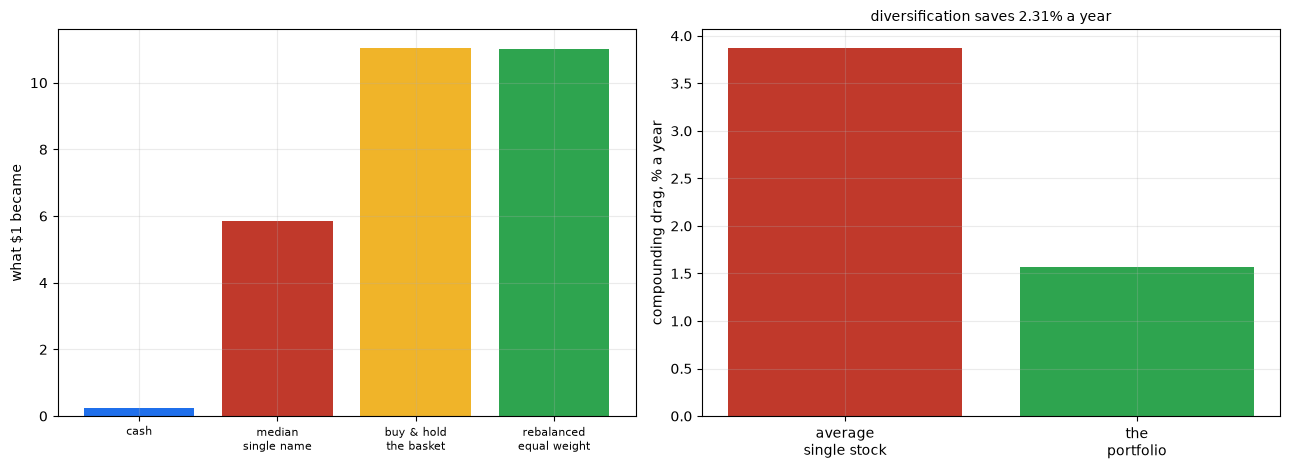

average single-name volatility 27.8% -> drag 3.87%/yr
portfolio volatility           17.7% -> drag 1.57%/yr


In [7]:
rec = st.index_reconciliation(R, cash)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
labels = ["cash", "median\nsingle name", "buy & hold\nthe basket",
          "rebalanced\nequal weight"]
vals = [rec["cash"], rec["median_single"], rec["buy_and_hold_basket"],
        rec["rebalanced_equal_weight"]]
axes[0].bar(labels, vals, color=["#1f6feb", "#c0392b", "#f0b429", "#2ea44f"])
axes[0].set_ylabel("what $1 became")
plt.setp(axes[0].get_xticklabels(), fontsize=8)
axes[1].bar(["average\nsingle stock", "the\nportfolio"],
            [rec["single_drag"] * 100, rec["portfolio_drag"] * 100],
            color=["#c0392b", "#2ea44f"])
axes[1].set_ylabel("compounding drag, % a year")
axes[1].set_title(f"diversification saves {rec['drag_saved']:.2%} a year", fontsize=10)
plt.tight_layout(); plt.show()
print(f"average single-name volatility {rec['single_vol']:.1%} -> drag "
      f"{rec['single_drag']:.2%}/yr")
print(f"portfolio volatility           {rec['portfolio_vol']:.1%} -> drag "
      f"{rec['portfolio_drag']:.2%}/yr")

The drag is proportional to variance. Diversification cuts variance. So an index of the same
fifty names pays a much smaller compounding penalty than any of them does individually — and
that saving, compounded over decades, is the entire gap.

## 5 · What this means if you hold a few names

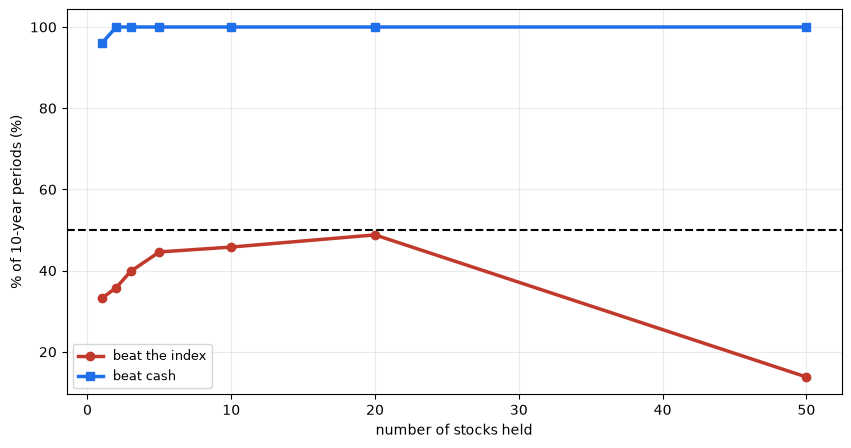

,share_beat_cash,share_beat_index,median_return,mean_return,p10,p90
n_stocks,,,,,,
1,0.9600,0.3320,2.3270,3.4980,0.4150,8.1320
2,1.0000,0.3580,2.6390,3.3980,0.9740,6.0730
3,1.0000,0.3980,2.9300,3.5820,1.3300,6.1330
5,1.0000,0.4460,3.0500,3.4750,1.6080,5.8090
10,1.0000,0.4580,3.2160,3.3910,2.0120,4.9910
20,1.0000,0.4880,3.2440,3.3920,2.3270,4.5950
50,1.0000,0.1380,3.3140,3.3470,2.7030,4.1670


In [8]:
odds = st.concentrated_portfolio_odds(R, cash, sizes=(1, 2, 3, 5, 10, 20, 50),
                                      horizon_years=10, n_draws=500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(odds.index, odds["share_beat_index"] * 100, "o-", lw=2.5, color="#c0392b",
        label="beat the index")
ax.plot(odds.index, odds["share_beat_cash"] * 100, "s-", lw=2.5, color="#1f6feb",
        label="beat cash")
ax.axhline(50, color="k", ls="--", lw=1.5)
ax.set_xlabel("number of stocks held")
ax.set_ylabel("% of 10-year periods (%)"); ax.legend(fontsize=9)
plt.show()
odds.round(3)

## 6 · The verdict

**Signal: Busted.** **Not on this basket, and the failure is the finding.** These 50 names all survived to 2026 — the exact opposite of Bessembinder's universe, which is every firm that ever listed and mostly delisted. Here **91%** of 10-year holding periods beat Treasury bills, against 67% at one year: the share beating cash **rises** with horizon, the reverse of the headline. So the claim is not a universal law about equities, and the useful question becomes what it takes to produce it. The mechanism is real and verified — measured drag across these names averaged 5.87% a year against a theoretical 5.90%, a correlation of 1.00 name by name — but the median compounds at roughly drift minus σ²/2, and these names' drift is large enough to absorb it. The condition is exact: the median beats cash while σ < sqrt(2·(drift − cash)). At an average drift of 16.8% against cash's 1.3%, that threshold is **55% volatility**, and these names average 33% — a headroom of 22%, with 2% of them over the line. Bessembinder's population — small caps and firms on their way to delisting — sits on the other side of that threshold. The synthetic control quantifies the survivorship half of the gap: removing simulated failures raises the median terminal wealth by 0.86×.

**Tradability: Mirage.** The implication is not "don't buy stocks", it is "don't buy few stocks", and the reconciliation makes that precise. Over the full sample the median single name returned 15.3× against cash's 0.6×, while the **rebalanced equal-weight basket of those same names** returned 414.2×. The index does not escape variance drag; it escapes most of it, because drag is proportional to σ² and diversification cuts the average single-name volatility of 33% to a portfolio 20% — worth 3.52% a year, compounding. Rebalancing is doing real work rather than housekeeping. Priced as odds over 10 years: a five-stock portfolio beat the index 43% of the time, a twenty-stock 51%, the full basket 14%. A concentrated book is not a slightly worse diversified one — it is a different bet, on the right tail, that most often loses.

## 7 · Going further \U0001F6AA

- **This is not an argument against stocks.** The mean is excellent and the index captures it.
  It is an argument against *few* stocks.
- **Rebalancing is not housekeeping.** It is the mechanism that keeps the portfolio's variance
  low, and variance is what the drag is charged on. A buy-and-hold basket slowly turns into a
  concentrated bet and loses that advantage.
- **The real cross-section is worse than this one.** These fifty all survived. Include the
  companies that did not and the median falls further — which is Bessembinder's actual sample.
- **If you concentrate anyway, know the price.** It is not extra risk in exchange for extra
  expected return. Expected return is unchanged; you are trading a likely small loss for an
  unlikely large gain.